In [1]:
!pip install --upgrade pip
# !pip install --upgrade google-cloud-vision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [19]:
from google.cloud import vision
import io
import os

# Replace with your actual path to the JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/kaggle/input/musait/manifest-canto-466706-v0-1bb68556dfe3.json"

In [20]:
SENTIMENTS_TO_LABELS = {'negative':0,'neutral':1,'positive':2}
LABELS_TO_SENTIMENTS = {0:'negative',1:'neutral',2:"positive"}

In [4]:
import pandas as pd
df = pd.read_csv("/kaggle/input/musait/MUSAIT__all_info_uniques.csv")
# df.head()

# Create crosstab
ct = pd.crosstab(df['sentiment'], df['img_or'])

prob_table = ct.div(ct.sum(axis=0), axis=1)

prob_table

img_or,box,horizontal,other,vertical
sentiment,,,,
negative,0.160396,0.450530,0.404255,0.097297
neutral,0.346535,0.340106,0.361702,0.213514
positive,0.493069,0.209364,0.234043,0.689189


In [5]:
prob_table.to_csv("p_givenOrientationsTable.csv")

In [21]:
# Define standard aspect ratios
standard_ratios = {
    "1:1": 1.0, # 1 BOX
    "4:3": 4/3, # 1.33 Horizontal
    "3:2": 3/2, # 1.5 Horizontal
    "16:9": 16/9, # 1.78 Horizontal
    "5:4": 5/4, # 1.25 Horizontal
    "21:9": 21/9, # 2.33 Horizontal
    "2:1": 2.0, # 2 Horizontal
    "7:5": 7/5, # 1.4 Horizontal
    # "A4 (1.41:1)": 1.41,
    "3:4": 3/4, # 0.75 Vertical
    "2:3": 2/3, # 0.67 Vertical
    "9:16": 9/16, # 0.5625 Vertical
    "5:7": 5/7, # 0.71 Vertical
    "4:5": 4/5, # 0.8 Vertical
    "A-series (1:√2)": 1/1.414, # 0.707 Vertical
    "2:5": 2/5, # 0.4 Vertical
    "Other":0
}


# Function to match image to closest standard aspect ratio
def closest_standard_ratio(width, height, tolerance=0.05):
    if height == 0:
        return "Invalid"
    ratio = width / height
    for name, std_ratio in standard_ratios.items():
        if abs(ratio - std_ratio) <= tolerance:
            return name
    return "Other"

In [22]:
aspect_ratio_orientation = {
    # --- Box-like (almost square) ---
    "1:1": "box",

    # --- Horizontal (landscape) ---
    "4:3": "horizontal",      # 1.33
    "3:2": "horizontal",      # 1.5
    "16:9": "horizontal",     # 1.78
    "5:4": "horizontal",      # 1.25
    "21:9": "horizontal",     # 2.33
    "2:1": "horizontal",      # 2.0
    "7:5": "horizontal",      # 1.4
    "A4 (1.41:1)": "horizontal",  # 1.41

    # --- Vertical (portrait) ---
    "3:4": "vertical",        # 0.75
    "2:3": "vertical",        # 0.666
    "9:16": "vertical",       # 0.5625
    "5:7": "vertical",        # 0.714
    "4:5": "vertical",        # 0.8
    "A-series (1:√2)": "vertical",  # ≈0.707
    "2:5": "vertical",        # 0.4

    # --- Catch-all ---
    # "Other": "other"
    "Other": "box"
}

# One-sample test

### Text
if text-detected:
    Extract OCR after producing the text area bounding region
else:
    Produce image caption

Use DistilRoBERTa for sentiment classification on the text available


### Visual
Produce the image through CLIP for sentiment classification


Have the image orientation weights
Have the text-image orientation weights

Accordingly produce the sentiment probabilities
Fuse them using the text-image-ratio

In [8]:
or_dist = pd.read_csv("/kaggle/working/p_givenOrientationsTable.csv", index_col=0)

In [9]:
list(or_dist["box"])

[0.1603960396039604, 0.3465346534653465, 0.493069306930693]

In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilroberta-base"
num_labels = 3

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_name)
text_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
text_model.to(device)

# Load your fine-tuned weights
# state_dict = torch.load("/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt", map_location=torch.device('cpu'))
state_dict = torch.load("/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt", map_location=device)
text_model.load_state_dict(state_dict)  # Should match now
text_model.eval()

2025-09-05 17:15:11.278928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757092511.297337     168 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757092511.302824     168 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cuda


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [6]:
def preprocess(text, tokenizer, max_length=128):
    return tokenizer(
        text,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

In [7]:
from transformers import AutoTokenizer

text_tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')

In [13]:
# Input text
text = "I have not seen such a wonderful movie ever in my lifetime, and I was so happy"

# Tokenize
inputs = preprocess(text, text_tokenizer).to(device)
# inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding=True)

# Inference
with torch.no_grad():
    outputs = text_model(**inputs)
    logits = outputs.logits
    print(logits)
    probs = torch.nn.functional.softmax(logits, dim=1)

# Print result
print("Probabilities:", probs.squeeze().tolist())
predicted_class = torch.argmax(probs, dim=1).item()
print("Predicted class:", predicted_class)


tensor([[-1.0274, -2.3471,  3.3762]], device='cuda:0')
Probabilities: [0.012046060524880886, 0.0032188526820391417, 0.9847351312637329]
Predicted class: 2


In [14]:
from PIL import Image
import ast

# Load your image
image_path = "/kaggle/input/musait/basket_unique/positive_001.jpeg"
with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

# Initialize the Vision client
client = vision.ImageAnnotatorClient()

image = vision.Image(content=content)
text = None

# Perform OCR (Text Detection)
response = client.text_detection(image=image)
texts = response.text_annotations

# Get dimensions using PIL
pil_image = Image.open(io.BytesIO(content))
img_width, img_height = pil_image.size

# Calculate area
img_area = img_width * img_height
img_ar = closest_standard_ratio(img_width, img_height)
img_ort = aspect_ratio_orientation[img_ar]
img_ort_sentiments = list(or_dist[img_ort])
alpha = 0 # txt_weightage

# Display results
if texts:
    print("Detected text:\n")
    print(texts[0].description)
    text = texts[0].description
    bounding_poly = texts[0].bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    # points = ast.literal_eval(coordinates)
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
else:
    print("No text detected.")


img_weightage = 1-alpha

ort_sent_res = [alpha * p + (1 - alpha) * q for p, q in zip(txt_ort_sentiments, img_ort_sentiments)]
# ort_sent_res = ( * txt_weightage) + ( * img_weightage)
print(ort_sent_res)

Detected text:

Listen to your
soul. It always
knows when it's
time to start a
new chapter in
your life.
Via (Dark Secrets)
[0.0972972972972973, 0.2135135135135135, 0.6891891891891891]


In [15]:
text

"Listen to your\nsoul. It always\nknows when it's\ntime to start a\nnew chapter in\nyour life.\nVia (Dark Secrets)"

In [16]:
# Tokenize
inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

# Inference
with torch.no_grad():
    outputs = text_model(**inputs)
    logits = outputs.logits
    print(logits)
    probs = torch.nn.functional.softmax(logits, dim=1)

# Print result
print("Probabilities:", probs.squeeze().tolist())

print(texts[0])

tensor([[-1.6547, -2.8223,  4.5125]], device='cuda:0')
Probabilities: [0.002091327216476202, 0.0006506827776320279, 0.9972579479217529]
locale: "en"
description: "Listen to your\nsoul. It always\nknows when it\'s\ntime to start a\nnew chapter in\nyour life.\nVia (Dark Secrets)"
bounding_poly {
  vertices {
    x: 176
    y: 251
  }
  vertices {
    x: 556
    y: 251
  }
  vertices {
    x: 556
    y: 697
  }
  vertices {
    x: 176
    y: 697
  }
}



In [23]:
from PIL import Image
import ast

def image_orientation(image_path):
    # Load your image
    # image_path = "/kaggle/input/musait/basket_unique/positive_001.jpeg"
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    # Get dimensions using PIL
    pil_image = Image.open(io.BytesIO(content))
    img_width, img_height = pil_image.size
    img_area = img_width*img_height
    
    # Calculate area
    img_area = img_width * img_height
    img_ar = closest_standard_ratio(img_width, img_height)
    img_ort = aspect_ratio_orientation[img_ar]
    img_ort_sentiments = list(or_dist[img_ort])
    return img_ort_sentiments, img_area

def check_text_detection(image_path):
    # Load your image
    # image_path = "/kaggle/input/musait/basket_unique/positive_001.jpeg"
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()
    
    # Initialize the Vision client
    client = vision.ImageAnnotatorClient()
    
    image = vision.Image(content=content)
    text = None
    
    # Perform OCR (Text Detection)
    response = client.text_detection(image=image)
    texts = response.text_annotations
    return texts[0] if texts else False

def text_orientation(texts, img_area):
    text = texts.description
    bounding_poly = texts.bounding_poly
    coordinates = []
    for vertex in bounding_poly.vertices:
        coordinates.append({"x": vertex.x, "y": vertex.y})
    # points = ast.literal_eval(coordinates)
    
    x_values = [point['x'] for point in coordinates]
    y_values = [point['y'] for point in coordinates]
    txt_width = max(x_values) - min(x_values)
    txt_height = max(y_values) - min(y_values)

    txt_area = txt_width*txt_height
    txt_weightage = txt_area/img_area
    txt_ar = closest_standard_ratio(txt_width, txt_height)
    txt_ort = aspect_ratio_orientation[txt_ar]
    txt_ort_sentiments = list(or_dist[txt_ort])
    return txt_ort_sentiments, txt_weightage
    

# alpha = 0 # txt_weightage

# # Display results
# if texts:
#     print("Detected text:\n")
#     print(texts[0].description)
    
# else:
#     print("No text detected.")


# img_weightage = 1-alpha

# ort_sent_res = [alpha * p + (1 - alpha) * q for p, q in zip(txt_ort_sentiments, img_ort_sentiments)]
# # ort_sent_res = ( * txt_weightage) + ( * img_weightage)
# print(ort_sent_res)

In [18]:
import os
from tqdm.notebook import tqdm 
import numpy as np

root = "/kaggle/input/musait/basket_unique"
all_img = os.listdir(root)
all_img.sort()
class_counts = [0,0,0]
class_labels = ['negative', 'neutral', 'positive']

for img_name in tqdm(all_img, desc="Testing on MuSAIT database: "):
    sentiment = img_name.split("_")[0]
    label = SENTIMENTS_TO_LABELS[sentiment]
    class_counts[label]+=1

Testing on MuSAIT database:   0%|          | 0/2054 [00:00<?, ?it/s]

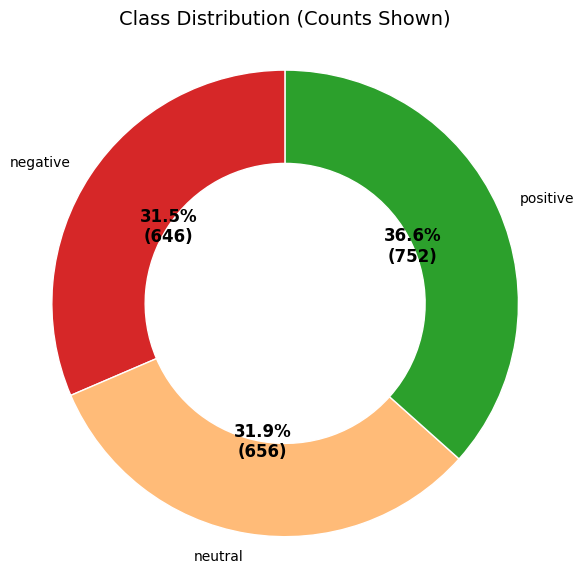

In [19]:
import matplotlib.pyplot as plt

# Normalize counts for colormap
norm = plt.Normalize(min(class_counts), max(class_counts))
cmap = plt.get_cmap("coolwarm")
# colors = cmap(norm(class_counts))
colors = ['#D62728', '#FFBB78', '#2CA02C']

# Function to display raw counts
def make_autopct(counts):
    def inner_autopct(pct):
        total = sum(counts)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return inner_autopct

# Create donut chart
plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(
    class_counts,
    labels=class_labels,
    colors=colors,
    autopct=make_autopct(class_counts),
    startangle=90,
    wedgeprops={'width': 0.4, 'edgecolor': 'w'}
)

# Style the count labels
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.axis('equal')
plt.title("Class Distribution (Counts Shown)", fontsize=14)
plt.tight_layout()
plt.savefig("donut_chart_with_counts.png", dpi=300)
plt.show()
plt.close()

# Ablation Study

## Only-orientation channel

In [35]:
import os
from tqdm.notebook import tqdm 
import numpy as np

root = "/kaggle/input/musait/basket_unique"
all_img = os.listdir(root)
all_img.sort()
# img_name = "positive_109.jpg"


y_actual, y_pred = [],[] # y denotes LABELS


# prob_1: probability based on IMAGE ORIENTATION
# prob_2: probability based on TEXT ORIENTATION
# prob_ort: FUSED probability based on ORIENTATION



for img_name in tqdm(all_img, desc="Testing on MuSAIT database: "):
    # print(img_name)
    actual_sentiment = img_name.split('_')[0]
    actual_label = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_actual += [actual_label]
    
    filepath = os.path.join(root, img_name)
    
    # print(filepath)
    prob_1, img_area = image_orientation(filepath)
    prob_1 = np.array(prob_1)
    
    texts = check_text_detection(filepath)
    
    prob_2, alpha = None, 0
    prob = []
    
    if texts:
        prob_2, alpha = text_orientation(texts, img_area)
        prob_2 = np.array(prob_2)
        prob = (1-alpha)*prob_1 + alpha*prob_2
        # print(texts.description)
    else:
        prob = prob_1
    
    pred_class = np.argmax(prob)
    # print(prob)
    # print(pred_class)
    y_pred += [pred_class]
    # print(y_pred)
    # print(y_actual)
    # break

Testing on MuSAIT database:   0%|          | 0/2054 [00:00<?, ?it/s]

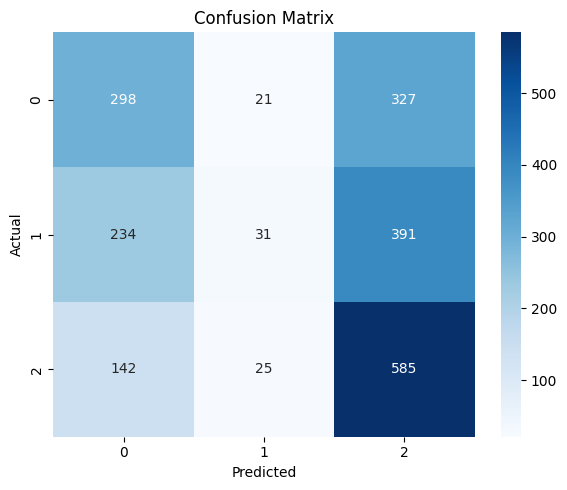

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Example data (replace these with your actual lists)
y_true = y_actual
# y_pred = [0, 2, 1, 1, 0, 2, 1]

# Classes (in case not all are present in y_true/y_pred)
classes = [0, 1, 2]

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

# ----- Classification Report -----
report = classification_report(y_true, y_pred, labels=classes, output_dict=True)
# print(report)
# Visualize classification report as heatmap
# report_matrix = np.array([[report[str(label)]['precision'],
#                            report[str(label)]['recall'],
#                            report[str(label)]['f1-score']] for label in classes])

# plt.figure(figsize=(8,4))
# sns.heatmap(report_matrix, annot=True, cmap="YlGnBu", xticklabels=["Precision", "Recall", "F1-score"], yticklabels=classes)
# plt.title("Classification Report")
# plt.tight_layout()
# plt.savefig("classification_report.png")
# plt.show()
# plt.close()


In [37]:
report

{'0': {'precision': 0.4421364985163205,
  'recall': 0.4613003095975232,
  'f1-score': 0.4515151515151515,
  'support': 646},
 '1': {'precision': 0.4025974025974026,
  'recall': 0.04725609756097561,
  'f1-score': 0.08458390177353342,
  'support': 656},
 '2': {'precision': 0.44896392939370683,
  'recall': 0.7779255319148937,
  'f1-score': 0.5693430656934306,
  'support': 752},
 'accuracy': 0.44498539435248297,
 'macro avg': {'precision': 0.4312326101691433,
  'recall': 0.4288273130244642,
  'f1-score': 0.36848070632737184,
  'support': 2054},
 'weighted avg': {'precision': 0.4320082517280947,
  'recall': 0.44498539435248297,
  'f1-score': 0.3774643684730699,
  'support': 2054}}

In [25]:
cm

array([[172,   0, 474],
       [110,   0, 546],
       [ 63,   0, 689]])

## Only-DistilRoBERTa

### BLIP-2

In [16]:
!pip install --upgrade pip ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.8.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.8.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [ ]:
import os

!pip install -q -U bitsandbytes
!pip install -q -U accelerate
!pip install -q -U transformers

print("Done installing! Restarting kernel...")
os.kill(os.getpid(), 9)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.5.1 which is incompatible.


In [8]:
import requests
from PIL import Image
# from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

# Set the device to GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

# Load the BLIP-2 processor and model from Hugging Face
# This will download the model weights, which might take a few minutes
# processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
# model = Blip2ForConditionalGeneration.from_pretrained(
#     "Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16
# )

from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

blip_model.to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [9]:
# import torch
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


negative_019.jpg __________________________________________________
Caption: a woman carrying a child in a flooded street


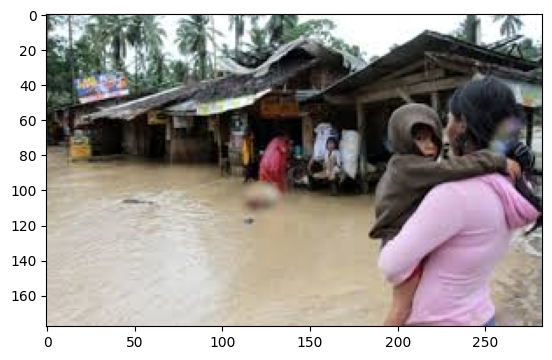

In [5]:
import matplotlib.pyplot as plt
# img_url_custom = '/kaggle/input/musait/dataset/basket/negative_003.jpg'
# img_url_custom = '/kaggle/input/musait/dataset/basket/negative_014.jpg'
img_url_custom = '/kaggle/input/musait/dataset/basket/negative_019.jpg'
# img_url_custom = '/kaggle/input/musait/dataset/basket/negative_054.jpg'
# img_url_custom = '/kaggle/input/musait/dataset/basket/positive_121.jpg'
# img_url_custom = '/kaggle/input/musait/basket_unique/negative_034.jpg'

raw_image = Image.open(img_url_custom).convert('RGB')

inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
    
# Generate the caption
generated_ids = blip_model.generate(**inputs)

# Decode the generated IDs to a text string
generated_text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

# Display the caption
split = img_url_custom.split("/")[-1]
print(f"{split}","_"*50)
plt.imshow(raw_image)
print(f"Caption: {generated_text}")

In [27]:
import os
from tqdm.notebook import tqdm 
import numpy as np

root = "/kaggle/input/musait/basket_unique"
all_img = os.listdir(root)
all_img.sort()
# img_name = "positive_109.jpg"

y_actual, y_pred = [],[] # y denotes LABELS


# prob_1: probability based on IMAGE ORIENTATION
# prob_2: probability based on TEXT ORIENTATION
# prob_ort: FUSED probability based on ORIENTATION




for img_name in tqdm(all_img, desc="Testing on MuSAIT database: "):
    # print(img_name)
    actual_sentiment = img_name.split('_')[0]
    actual_label = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_actual += [actual_label]
    
    filepath = os.path.join(root, img_name)
    # print(filepath)
    
    prob_1, img_area = image_orientation(filepath)
    prob_1 = np.array(prob_1)
    
    texts = check_text_detection(filepath)
    
    prob_2, alpha = None, 0
    prob_ort = []
    text = None
    c = 0
    
    if texts:
        prob_2, alpha = text_orientation(texts, img_area)
        prob_2 = np.array(prob_2)
        prob_ort = (1 - alpha) * prob_1 + prob_2 * alpha
        # print(f"Filename: {img_name} contains \'",texts.description,"\'")
        text = texts.description
        # print(texts.description)
    else:
        prob_ort = prob_1
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        # Generate the caption
        generated_ids = blip_model.generate(**inputs)
        # Decode the generated IDs to a text string
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        # print("Generated Text: ",text)
        # print(f"Filename: {img_name}")
        c=1

    # text = texts
    # Tokenize
    inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        # print(logits)
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    # Print result
    prob_text = np.array(probs.squeeze().tolist())
    # print("Probabilities:", probs.squeeze().tolist())
    
    # pred_class = np.argmax(prob_ort)
    pred_class = np.argmax(prob_text)
    # print(prob)
    # print(pred_class)
    y_pred += [pred_class]
    # print(pred_class)
    # if c:
        # break
    # print(y_pred)
    # print(y_actual)
    # break

Testing on MuSAIT database:   0%|          | 0/2054 [00:00<?, ?it/s]

In [28]:
device

device(type='cuda')

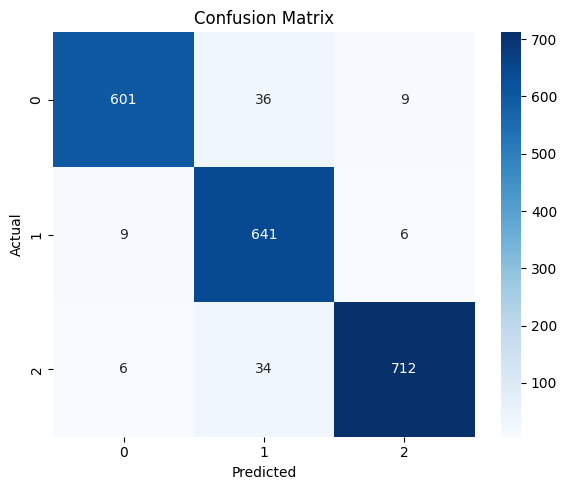

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Example data (replace these with your actual lists)
y_true = y_actual
# y_pred = [0, 2, 1, 1, 0, 2, 1]

# Classes (in case not all are present in y_true/y_pred)
classes = [0, 1, 2]

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

In [31]:
# ----- Classification Report -----
report = classification_report(y_true, y_pred, labels=classes)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       646
           1       0.90      0.98      0.94       656
           2       0.98      0.95      0.96       752

    accuracy                           0.95      2054
   macro avg       0.95      0.95      0.95      2054
weighted avg       0.95      0.95      0.95      2054



In [32]:
cm

array([[601,  36,   9],
       [  9, 641,   6],
       [  6,  34, 712]])

## Only CLIP

In [10]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'clip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'clip'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [11]:
import clip
import torch

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
# Load CLIP + Preprocess
clip_model, image_preprocess = clip.load("ViT-B/32", device=device)
print("Device in use: ",device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 151MiB/s]


Device in use:  cuda


In [12]:
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

In [13]:
# Image encoder only
image_encoder = clip_model.visual

# Define classifier
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)



image_model = CLIPClassifier(image_encoder, embed_dim=512, num_classes=3).to(device)

In [14]:
# Load best model
image_model.load_state_dict(torch.load("/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"))
image_model.eval()

CLIPClassifier(
  (encoder): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)

In [15]:
import os
from PIL import Image
from tqdm.notebook import tqdm 
import numpy as np

root = "/kaggle/input/musait/dataset/basket"
all_img = os.listdir(root)
all_img.sort()
# img_name = "positive_109.jpg"

y_actual, y_pred = [],[] # y denotes LABELS


# prob_1: probability based on IMAGE ORIENTATION
# prob_2: probability based on TEXT ORIENTATION
# prob_ort: FUSED probability based on ORIENTATION




for img_name in tqdm(all_img, desc="Testing on MuSAIT database: "):
    # print(img_name)
    actual_sentiment = img_name.split('_')[0]
    actual_label = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_actual += [actual_label]
    
    filepath = os.path.join(root, img_name)
    image = Image.open(filepath)
    image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)

    pred_class = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        pred_class = output.argmax(dim=1).item()
        # Decode the predicted index back to the class name
        # Store the result
        y_pred += [pred_class]
        # print(output)
        # print(type(output))
        # break
    # print(f"Predicted class for file {img_name}: {pred_class}")
    # break

Testing on MuSAIT database:   0%|          | 0/2875 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


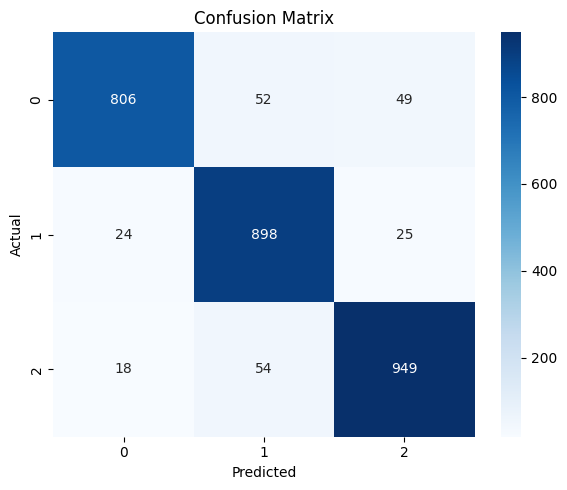

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Example data (replace these with your actual lists)
y_true = y_actual
# y_pred = [0, 2, 1, 1, 0, 2, 1]

# Classes (in case not all are present in y_true/y_pred)
classes = [0, 1, 2]

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

In [17]:
# ----- Classification Report -----
report = classification_report(y_true, y_pred, labels=classes)
print(report)

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       907
           1       0.89      0.95      0.92       947
           2       0.93      0.93      0.93      1021

    accuracy                           0.92      2875
   macro avg       0.92      0.92      0.92      2875
weighted avg       0.92      0.92      0.92      2875



## DistilRoBERTa + BLIP + CLIP

In [24]:
import os
from tqdm.notebook import tqdm 
import numpy as np
import torch.nn.functional as F

# root = "/kaggle/input/musait/basket_unique"
root = "/kaggle/input/musait/dataset/basket"
all_img = os.listdir(root)
all_img.sort()
# img_name = "positive_109.jpg"

y_actual, y_pred = [],[] # y denotes LABELS


# prob_1: probability based on IMAGE ORIENTATION
# prob_2: probability based on TEXT ORIENTATION
# prob_ort: FUSED probability based on ORIENTATION




for img_name in tqdm(all_img, desc="Testing on MuSAIT database: "):
    # print(img_name)
    actual_sentiment = img_name.split('_')[0]
    actual_label = SENTIMENTS_TO_LABELS[actual_sentiment]
    y_actual += [actual_label]
    
    filepath = os.path.join(root, img_name)
    # print(filepath)
    
    # prob_1, img_area = image_orientation(filepath)
    # prob_1 = np.array(prob_1)
    
    texts = check_text_detection(filepath)
    
    # prob_2, alpha = None, 0
    # prob_ort = []
    text = None
    c = 0
    
    if texts:
        # prob_2, alpha = text_orientation(texts, img_area)
        # prob_2 = np.array(prob_2)
        # prob_ort = (1 - alpha) * prob_1 + prob_2 * alpha
        # print(f"Filename: {img_name} contains \'",texts.description,"\'")
        text = texts.description
        # print(texts.description)
    else:
        # prob_ort = prob_1
        # BLIP-2 Image Caption Generation
        raw_image = Image.open(filepath).convert('RGB')
        inputs = blip_processor(images=raw_image, return_tensors="pt").to(device, torch.float16)
        # Generate the caption
        generated_ids = blip_model.generate(**inputs)
        # Decode the generated IDs to a text string
        text = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        # print("Generated Text: ",text)
        # print(f"Filename: {img_name}")
        c=1

    # text = texts
    # Tokenize
    inputs = text_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = text_model(**inputs)
        logits = outputs.logits
        # print(logits)
        probs = torch.nn.functional.softmax(logits, dim=1)
    
    # Print result
    prob_text = np.array(probs.squeeze().tolist())
    # print("Probabilities:", probs.squeeze().tolist())

    image = Image.open(filepath)
    image_preprocessed = image_preprocess(image).unsqueeze(0).to(device)

    pred_class_clip = -1
    
    # Inference
    with torch.no_grad():
        output = image_model(image_preprocessed)
        # Get the predicted class index
        
        probs = F.softmax(output, dim=1)  # Shape: (1, 3)
        # Step 2: Convert to CPU and to list
        prob_img = np.array(probs.squeeze().tolist())  # Shape: (3,)
        # pred_class_clip = output.argmax(dim=1).item()
        # Decode the predicted index back to the class name
        # Store the result
        # y_pred += [pred_class]

    
    # pred_class = np.argmax(prob_ort)
    prob_total = (prob_text + prob_img)/2
    pred_class = np.argmax(prob_total)
    # print(prob)
    # print(pred_class)
    y_pred += [pred_class]
    # print(pred_class)
    # if c:
    # break
    # print(y_pred)
    # print(y_actual)
    # break

Testing on MuSAIT database:   0%|          | 0/2875 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


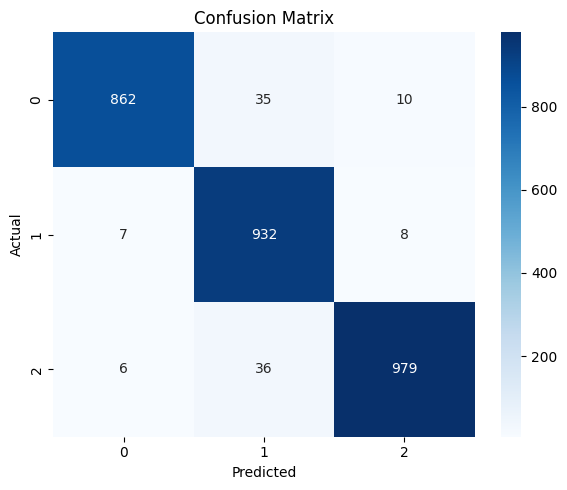

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Example data (replace these with your actual lists)
y_true = y_actual
# y_pred = [0, 2, 1, 1, 0, 2, 1]

# Classes (in case not all are present in y_true/y_pred)
classes = [0, 1, 2]

# ----- Confusion Matrix -----
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()
plt.close()

In [26]:
# ----- Classification Report -----
report = classification_report(y_true, y_pred, labels=classes)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       907
           1       0.93      0.98      0.96       947
           2       0.98      0.96      0.97      1021

    accuracy                           0.96      2875
   macro avg       0.97      0.96      0.96      2875
weighted avg       0.97      0.96      0.96      2875



# MUSAIT model

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, Blip2ForConditionalGeneration, Blip2Processor
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoProcessor, AutoModelForImageClassification
from PIL import Image

In [ ]:
# =============================================================================
# Step 1: Define the Ensemble Model Class
# This class will accept both text and image inputs.
# =============================================================================


class SentimentPipeline(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # 1. Load your pretrained models
        self.clip = AutoModel.from_pretrained("openai/clip-vit-base-patch32")
        self.distilroberta = AutoModel.from_pretrained("distilroberta-base")
        
        # Load BLIP-2 for captioning fallback
        self.blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
        self.blip_model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b")

        # 2. Define the fusion layer
        # The input size is the sum of the feature dimensions from both models
        clip_features_dim = self.clip.projection_dim # Example: 512
        roberta_features_dim = self.distilroberta.config.hidden_size # Example: 768
        
        self.fusion_head = nn.Sequential(
            nn.Linear(clip_features_dim + roberta_features_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image_pixels, ocr_input_ids=None, ocr_attention_mask=None):
        # --- Image Path ---
        # Get image features from CLIP's vision model
        image_features = self.clip.get_image_features(pixel_values=image_pixels)
        
        # --- Text Path (Conditional) ---
        if ocr_input_ids is not None:
            # Case 1: OCR text is available
            text_outputs = self.distilroberta(
                input_ids=ocr_input_ids, 
                attention_mask=ocr_attention_mask
            )
        else:
            # Case 2: No OCR text, generate caption with BLIP-2
            caption_inputs = self.blip_processor(images=image_pixels, return_tensors="pt")
            generated_ids = self.blip_model.generate(**caption_inputs)
            caption = self.blip_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            
            # Now, tokenize the caption and pass it to DistilRoBERTa
            # (You'd need the roberta_tokenizer here)
            # caption_tokens = roberta_tokenizer(caption, return_tensors="pt")
            # text_outputs = self.distilroberta(**caption_tokens)
            pass # Placeholder for caption tokenizing logic

        # Extract the [CLS] token's hidden state as the text feature
        text_features = text_outputs.last_hidden_state[:, 0, :]

        # --- FUSION ---
        # Concatenate the features from both paths
        combined_features = torch.cat((image_features, text_features), dim=1)
        
        # Pass through the final fusion head to get sentiment logits
        final_logits = self.fusion_head(combined_features)
        
        return final_logits

In [ ]:
# =============================================================================
# Step 2: Load Models, Tokenizer, Processor and Create the Ensemble
# =============================================================================

if __name__ == '__main__':
    # --- Configuration ---
    # 1. UPDATE these to the base models you used for fine-tuning
    DISTILROBERTA_MODEL_NAME = "distilroberta-base"
    CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
    
    # 2. UPDATE these paths to your saved custom model weights
    TEXT_MODEL_PATH = "/kaggle/input/best-models-musait/TSA/DistilRoBERTa__best_model.pt"
    IMAGE_MODEL_PATH = "/kaggle/input/best-models-musait/VSA/CLIP__best_model.pt"

    # 3. UPDATE with your sample data
    SAMPLE_IMAGE_PATH = "path/to/your/sample_image.jpg"
    SAMPLE_OCR_TEXT = "This is the text extracted from the image by OCR."
    
    # --- Setup ---
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # --- Load Text Model (DistilRoBERTa) ---
    print("Loading DistilRoBERTa model and tokenizer...")
    # Load the architecture
    text_model_architecture = AutoModelForSequenceClassification.from_pretrained(DISTILROBERTA_MODEL_NAME, num_labels=3) # Assuming 3 labels: pos, neg, neu
    # Load your fine-tuned weights
    text_model_architecture.load_state_dict(torch.load(TEXT_MODEL_PATH, map_location=device))
    text_model = text_model_architecture.to(device)
    text_model.eval()
    
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(DISTILROBERTA_MODEL_NAME)
    
    # --- Load Image Model (CLIP Vision) ---
    print("Loading CLIP vision model and processor...")
    # It's assumed you added a classification head to the CLIP vision model.
    # We load the base vision model architecture and then your weights.
    image_model_architecture = AutoModelForImageClassification.from_pretrained(CLIP_MODEL_NAME, num_labels=3, ignore_mismatched_sizes=True) # ignore_mismatched_sizes is needed for custom head
    # Load your fine-tuned weights
    image_model_architecture.load_state_dict(torch.load(IMAGE_MODEL_PATH, map_location=device))
    image_model = image_model_architecture.to(device)
    image_model.eval()

    # Load the image processor
    processor = AutoProcessor.from_pretrained(CLIP_MODEL_NAME)
    
    # --- Create the Ensemble Model ---
    ensemble_model = MultimodalEnsemble(text_model=text_model, image_model=image_model)
    print("\n✅ Multimodal ensemble model created successfully!")
    
    # =========================================================================
    # Step 3: Preprocess Inputs and Use the Ensemble for Inference
    # =========================================================================
    
    print("\n--- Running Inference ---")
    
    # --- Preprocess the text input ---
    text_inputs = tokenizer(SAMPLE_OCR_TEXT, return_tensors="pt", padding=True, truncation=True, max_length=512)
    input_ids = text_inputs["input_ids"].to(device)
    attention_mask = text_inputs["attention_mask"].to(device)
    
    # --- Preprocess the image input ---
    try:
        image = Image.open(SAMPLE_IMAGE_PATH)
        image_inputs = processor(images=image, return_tensors="pt")
        pixel_values = image_inputs["pixel_values"].to(device)
    except FileNotFoundError:
        print(f"Warning: Sample image not found at '{SAMPLE_IMAGE_PATH}'. Using a dummy image tensor.")
        pixel_values = torch.randn(1, 3, 224, 224).to(device) # Dummy tensor

    # --- Perform Inference ---
    with torch.no_grad():
        final_logits = ensemble_model(input_ids=input_ids, attention_mask=attention_mask, pixel_values=pixel_values)
    
    # --- Get the Final Prediction ---
    probabilities = F.softmax(final_logits, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()
    
    # Map index to label (assuming you have a mapping)
    # You should replace this with your actual labels
    class_labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
    predicted_label = class_labels.get(predicted_class_idx, "Unknown")
    
    print(f"\nOCR Text: '{SAMPLE_OCR_TEXT}'")
    print(f"Image Path: '{SAMPLE_IMAGE_PATH}'")
    print(f"\nEnsemble Logits: {final_logits.cpu().numpy()}")
    print(f"Final Probabilities: {probabilities.cpu().numpy()}")
    print(f"🏆 Predicted Sentiment: **{predicted_label}** (Class Index: {predicted_class_idx})")


# Template

**Option 1: End-to-End Fine-Tuning**
- All parts (Model A, B, and fusion layer) are trained together.
- Allows the pretrained models to adapt to each other.

**Option 2: Frozen Backbone + Train Fusion Layer**
- Freeze Model A and B to preserve their pretrained knowledge.
- Only train the fusion logic and final classifier.
- Useful if you have limited data or want faster training.

______________________________________________________ **Example model setup** ___________________________________________________________

## Architecture

In [ ]:
import torch
import torch.nn as nn

class EnsembleModel(nn.Module):
    def __init__(self, model_a, model_b, fusion='concat'):
        super().__init__()
        self.model_a = model_a
        self.model_b = model_b
        self.fusion = fusion  # 'concat', 'add', or custom logic

        # Example: Assume model_a and model_b output vectors of size 768
        fusion_output_size = 768 * 2 if fusion == 'concat' else 768

        self.classifier = nn.Linear(fusion_output_size, num_classes)

    def forward(self, x):
        out_a = self.model_a(x)  # Shape: (batch_size, 768)
        out_b = self.model_b(x)  # Shape: (batch_size, 768)

        if self.fusion == 'concat':
            fused = torch.cat([out_a, out_b], dim=1)
        elif self.fusion == 'add':
            fused = out_a + out_b
        else:
            raise ValueError("Unsupported fusion method")

        return self.classifier(fused)

## Training Loop

In [ ]:
model = EnsembleModel(pretrained_a, pretrained_b, fusion='concat')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

for x_batch, y_batch in dataloader:
    logits = model(x_batch)
    loss = loss_fn(logits, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

## Freezing Pretrained Submodels

In [ ]:
for param in model.model_a.parameters():
    param.requires_grad = False

for param in model.model_b.parameters():
    param.requires_grad = False

## Tips and notes on Inputs and Outputs

- If models A and B take different inputs, handle that in forward().
- If they output different shapes, you may need to add a projection layer (e.g., nn.Linear) to align sizes before fusion.

**Tips**
- Use pretrained encoders from Hugging Face, torchvision, etc.
- Add dropout, batch norm, or attention between the fusion and classifier if performance needs tuning.
- You can use learned fusion methods (e.g., gated fusion, transformer attention between outputs) for better performance.